全2試合
データ: 90件

最新3試合:
  20260329 vs レジン (19-25) 44ラリー
  20260322 vs ネオ (21-25) 46ラリー

=== データ型確認 ===
date          object
score_us       int64
score_them     int64
rotation       int64
serve_team    object
point_team    object
dtype: object

=== サンプル ===
        date opponent  score_us  score_them  rotation serve_team point_team  \
85  20260329      レジン        18          22         5        レジン       自チーム   
86  20260329      レジン        18          23         6       自チーム        レジン   
87  20260329      レジン        19          23         6        レジン       自チーム   
88  20260329      レジン        19          24         1       自チーム        レジン   
89  20260329      レジン        19          25         1        レジン        レジン   

   result  
85     得点  
86     ミス  
87     得点  
88     ミス  
89     ミス  

=== 20260329 vs レジン ===
  スコア: 19-25 (負)
  SO率: 50.0% BRK率: 35.0%
  キャッチ A:4 B:0 C:14 D:2
  攻撃効率: 30.6%

=== 20260322 vs ネオ ===
  スコア: 21-25 (負)
  SO率: 48.0% BRK率: 42.9%
  キャッチ A:4 B:3 C:12 D:3
  攻

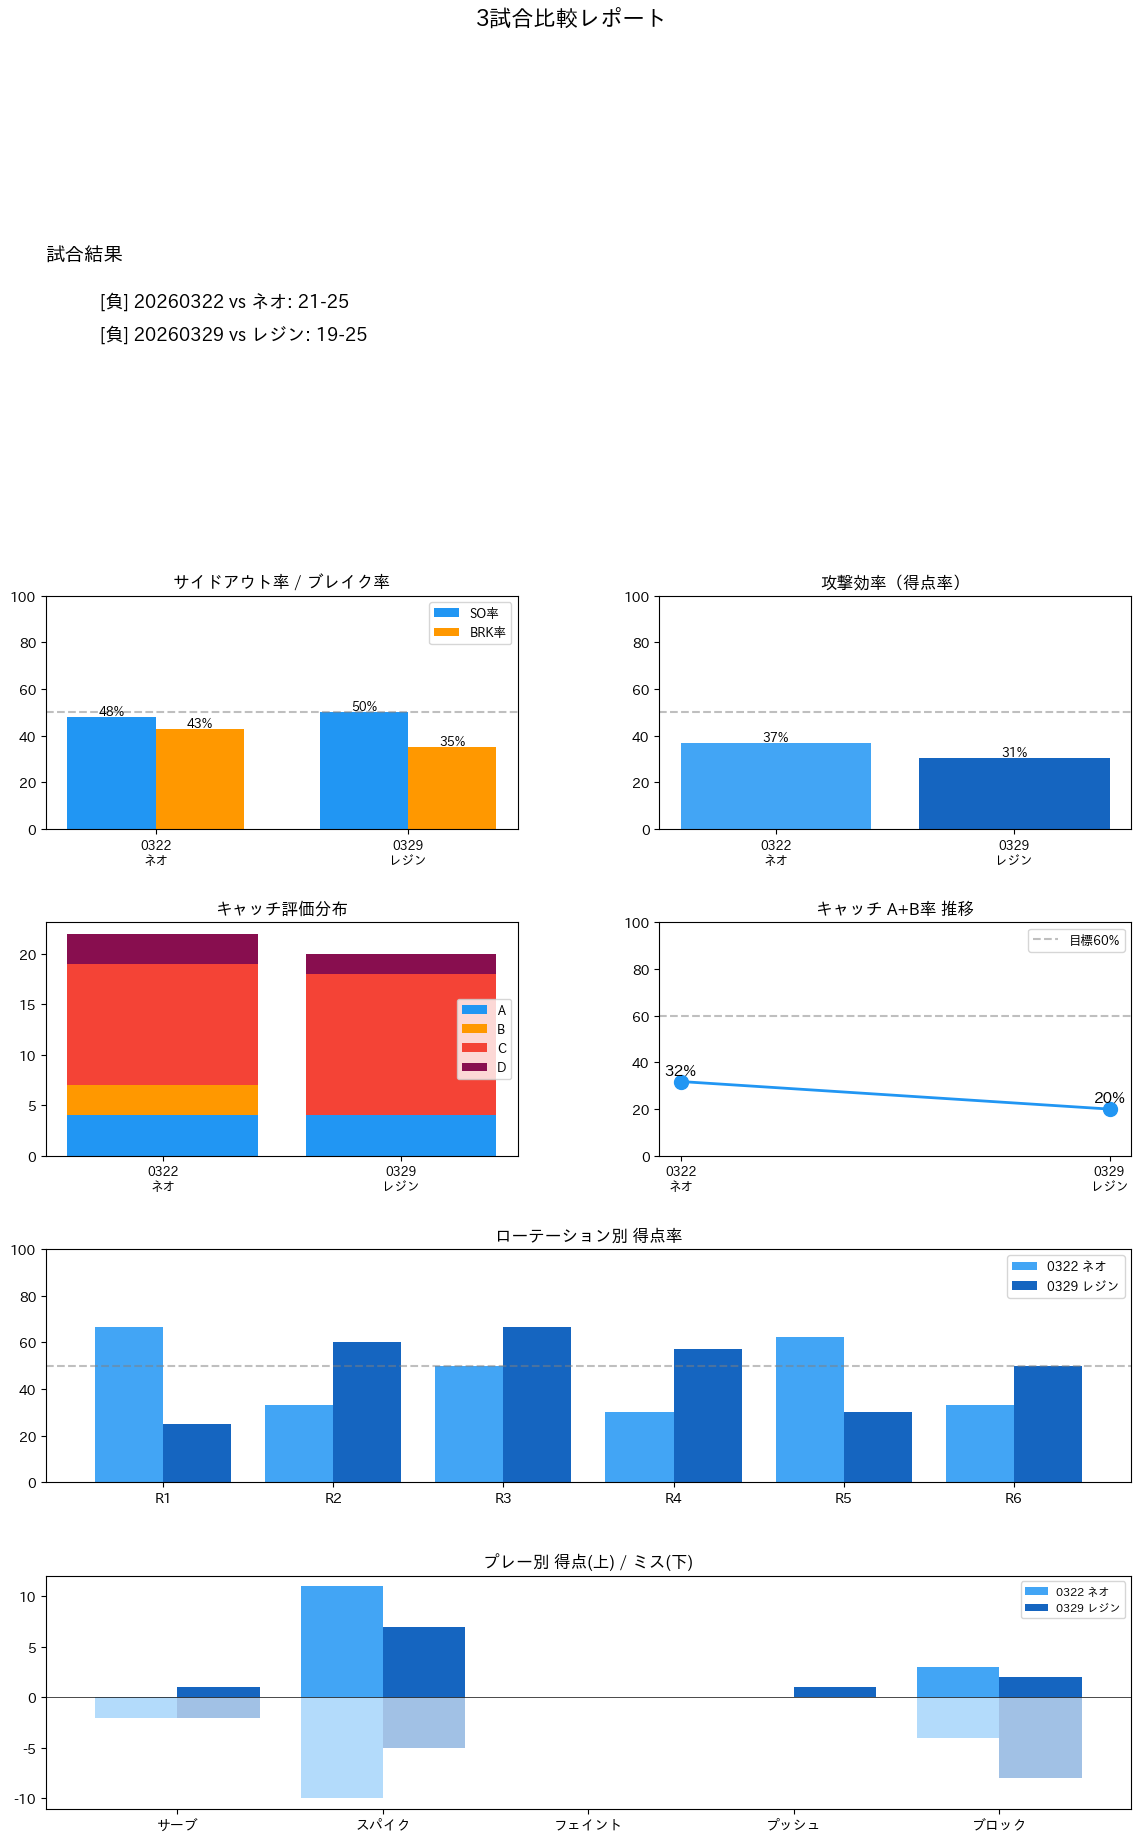

グラフ生成完了


In [9]:
# セル1: セットアップ + データ読み込み
# フォント設定（japanize-matplotlib の前に実行）
!pip install japanize-matplotlib -q

import matplotlib
import matplotlib.pyplot as plt

# 日本語フォントを確実に設定
plt.rcParams['font.family'] = 'IPAexGothic'
plt.rcParams['axes.unicode_minus'] = False

import japanize_matplotlib

!pip install notion-client japanize-matplotlib -q

from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import japanize_matplotlib
from notion_client import Client
import requests, base64
import numpy as np

# === 設定 ===
SHEET_NAME = 'バレースタッツ'
NOTION_TOKEN = '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'  # ← Step1でコピーしたキー
PAGE_ID = '331feaabd15e80b092a8f392c9157be3'           # ← スタッツ分析ページのID

# スプシ接続
# スプシ接続
creds, _ = default()
gc = gspread.authorize(creds)
ss = gc.open(SHEET_NAME)
ws = ss.worksheet('生データ')
df = pd.DataFrame(ws.get_all_records())

# === データ型の修正 ===
# 数値列を確実に数値に変換
for col in ['score_us','score_them','set','rotation']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# 文字列列の空白処理
str_cols = ['date','opponent','point_team','serve_team','team',
            'player','play_type','result','result_detail',
            'receive_grade','receiver','attack_type',
            'blocker_count','zone_from','zone_to','note']
for col in str_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace('','')

# date を文字列に統一
df['date'] = df['date'].astype(str)

# Notion接続
notion = Client(auth=NOTION_TOKEN)

# 試合を特定（date + opponent）
df['match_key'] = df['date'] + '_' + df['opponent']
matches = df.groupby('match_key').first()[['date','opponent']].reset_index()
matches = matches.sort_values('date', ascending=False)

# 最新3試合
recent_3 = matches.head(3)['match_key'].tolist()
print(f'全{len(matches)}試合')
print(f'データ: {len(df)}件')
print()
print('最新3試合:')
for mk in recent_3:
    m = df[df['match_key']==mk]
    l = m.iloc[-1]
    print(f"  {l['date']} vs {l['opponent']} ({l['score_us']}-{l['score_them']}) {len(m)}ラリー")

# データ確認
print()
print('=== データ型確認 ===')
print(df[['date','score_us','score_them','rotation','serve_team','point_team']].dtypes)
print()
print('=== サンプル ===')
print(df[['date','opponent','score_us','score_them','rotation','serve_team','point_team','result']].tail(5))

# セル2: ヘルパー関数

def upload_image(filepath):
    with open(filepath,'rb') as f:
        b64=base64.b64encode(f.read()).decode()
    res=requests.post('https://api.imgur.com/3/image',
        headers={'Authorization':'Client-ID 546c25a59c58ad7'},
        data={'image':b64})
    return res.json()['data']['link']

def safe_clear_page(pid):
    page=notion.pages.retrieve(page_id=pid)
    title=''
    try:
        for prop in page['properties'].values():
            if prop.get('type')=='title' and prop.get('title'):
                title=prop['title'][0]['plain_text']
    except:pass
    print(f'⚠️ クリア対象:「{title}」')
    if input('続行？(yes/no): ')!='yes':
        print('キャンセル');return False
    blocks=notion.blocks.children.list(block_id=pid)
    for b in blocks['results']:
        try:notion.blocks.delete(block_id=b['id'])
        except:pass
    return True

def add_heading(pid,text,level=2):
    notion.blocks.children.append(block_id=pid,children=[{
        'type':f'heading_{level}',
        f'heading_{level}':{'rich_text':[{'text':{'content':text}}]}
    }])

def add_text(pid,text):
    notion.blocks.children.append(block_id=pid,children=[{
        'type':'paragraph',
        'paragraph':{'rich_text':[{'text':{'content':text}}]}
    }])

def add_image(pid,url):
    notion.blocks.children.append(block_id=pid,children=[{
        'type':'image',
        'image':{'type':'external','external':{'url':url}}
    }])

def add_table(pid,headers,rows):
    w=len(headers)
    trs=[{'type':'table_row','table_row':{
        'cells':[[{'type':'text','text':{'content':str(h)}}] for h in headers]
    }}]
    for row in rows:
        trs.append({'type':'table_row','table_row':{
            'cells':[[{'type':'text','text':{'content':str(v)}}] for v in row]
        }})
    notion.blocks.children.append(block_id=pid,children=[{
        'type':'table','table':{
            'table_width':w,'has_column_header':True,
            'has_row_header':False,'children':trs
        }
    }])

def add_divider(pid):
    notion.blocks.children.append(block_id=pid,
        children=[{'type':'divider','divider':{}}])

# セル3: 試合ごとの分析関数

def analyze_match(mdf):
    """1試合分のデータから各指標を算出"""
    last = mdf.iloc[-1]
    total = len(mdf)

    # 基本情報
    info = {
        'date': str(last['date']),
        'opponent': str(last['opponent']),
        'score_us': int(last['score_us']),
        'score_them': int(last['score_them']),
        'sets': int(mdf['set'].max()),
        'rallies': total,
    }

    # 勝敗判定（セット数で判定するか、最終スコアで判定）
    if info['score_us'] > info['score_them']:
        info['result'] = '勝'
    elif info['score_us'] < info['score_them']:
        info['result'] = '負'
    else:
        info['result'] = '分'

    # サイドアウト率
    osv = mdf[mdf['serve_team'] != '自チーム']
    info['so_total'] = len(osv)
    info['so_won'] = len(osv[osv['point_team'] == '自チーム']) if len(osv) > 0 else 0
    info['so_rate'] = info['so_won'] / info['so_total'] * 100 if info['so_total'] > 0 else 0

    # ブレイク率
    usv = mdf[mdf['serve_team'] == '自チーム']
    info['brk_total'] = len(usv)
    info['brk_won'] = len(usv[usv['point_team'] == '自チーム']) if len(usv) > 0 else 0
    info['brk_rate'] = info['brk_won'] / info['brk_total'] * 100 if info['brk_total'] > 0 else 0

    # キャッチ評価
    recv = mdf[mdf['receive_grade'].isin(['A','B','C','D'])]
    info['recv_total'] = len(recv)
    for g in ['A','B','C','D']:
        info[f'recv_{g}'] = len(recv[recv['receive_grade'] == g])
    info['recv_a_rate'] = info['recv_A'] / info['recv_total'] * 100 if info['recv_total'] > 0 else 0
    info['recv_ab_rate'] = (info['recv_A'] + info['recv_B']) / info['recv_total'] * 100 if info['recv_total'] > 0 else 0

    # ローテーション別
    info['rot'] = {}
    for r in range(1, 7):
        rd = mdf[mdf['rotation'] == r]
        if len(rd) > 0:
            won = int((rd['point_team'] == '自チーム').sum())
            lost = int((rd['point_team'] != '自チーム').sum())
            total_r = won + lost
            info['rot'][r] = {
                'won': won,
                'lost': lost,
                'rate': won / total_r * 100 if total_r > 0 else 0
            }
        else:
            info['rot'][r] = {'won': 0, 'lost': 0, 'rate': 0}

    # 攻撃効率
    us = mdf[mdf['team'] == '自チーム']
    us_pt = us[us['result'] == '得点']
    us_ms = us[us['result'] == 'ミス']
    info['us_points'] = len(us_pt)
    info['us_miss'] = len(us_ms)
    total_us = info['us_points'] + info['us_miss']
    info['us_eff'] = info['us_points'] / total_us * 100 if total_us > 0 else 0

    # プレー別得点
    info['play_points'] = {}
    info['play_miss'] = {}
    for play in ['サーブ','スパイク','フェイント','プッシュ','ブロック']:
        info['play_points'][play] = len(us_pt[us_pt['play_type'] == play])
        info['play_miss'][play] = len(us_ms[us_ms['play_type'] == play])

    return info

# 3試合分の分析
results = []
for mk in recent_3:
    mdf = df[df['match_key'] == mk].copy()
    r = analyze_match(mdf)
    results.append(r)
    print(f"\n=== {r['date']} vs {r['opponent']} ===")
    print(f"  スコア: {r['score_us']}-{r['score_them']} ({r['result']})")
    print(f"  SO率: {r['so_rate']:.1f}% BRK率: {r['brk_rate']:.1f}%")
    print(f"  キャッチ A:{r['recv_A']} B:{r['recv_B']} C:{r['recv_C']} D:{r['recv_D']}")
    print(f"  攻撃効率: {r['us_eff']:.1f}%")

# 古い順に並べ替え
results = results[::-1]
labels = [f"{r['date']}\nvs {r['opponent']}" for r in results]
short_labels = [f"{r['date'][-4:]}\n{r['opponent']}" for r in results]

print('\n✅ 分析完了')

# セル4: グラフ生成（絵文字なし）

n_matches = len(results)
if n_matches == 0:
    print('データがありません')
    raise Exception('データなし')

colors_all = ['#90CAF9','#42A5F5','#1565C0']
colors = colors_all[-n_matches:]
x = np.arange(n_matches)

fig = plt.figure(figsize=(14, 20))
gs = gridspec.GridSpec(5, 2, hspace=0.4, wspace=0.3)

# --- 1. 試合結果サマリー ---
ax = fig.add_subplot(gs[0, :])
ax.axis('off')
summary = ''
for i,r in enumerate(results):
    marker = '[勝]' if r['result']=='勝' else '[負]' if r['result']=='負' else '[分]'
    summary += f"{marker} {r['date']} vs {r['opponent']}: {r['score_us']}-{r['score_them']}\n"
ax.text(0.05, 0.9, summary, transform=ax.transAxes, fontsize=13,
        verticalalignment='top', linespacing=2)
ax.set_title('試合結果', fontsize=14, fontweight='bold', loc='left')

# --- 2. サイドアウト率・ブレイク率 ---
ax = fig.add_subplot(gs[1, 0])
w = 0.35
so_rates = [r['so_rate'] for r in results]
brk_rates = [r['brk_rate'] for r in results]
bars1 = ax.bar(x-w/2, so_rates, w, label='SO率', color='#2196F3')
bars2 = ax.bar(x+w/2, brk_rates, w, label='BRK率', color='#FF9800')
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylim(0, 100)
ax.set_title('サイドアウト率 / ブレイク率')
ax.legend(fontsize=9)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=9)

# --- 3. 攻撃効率 ---
ax = fig.add_subplot(gs[1, 1])
effs = [r['us_eff'] for r in results]
bars = ax.bar(x, effs, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylim(0, 100)
ax.set_title('攻撃効率（得点率）')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.0f}%', ha='center', fontsize=9)

# --- 4. キャッチ評価分布 ---
ax = fig.add_subplot(gs[2, 0])
grades = ['A','B','C','D']
grade_colors = {'A':'#2196F3','B':'#FF9800','C':'#f44336','D':'#880E4F'}
bottom = np.zeros(n_matches)
for g in grades:
    vals = [r[f'recv_{g}'] for r in results]
    ax.bar(x, vals, bottom=bottom, label=g, color=grade_colors[g])
    bottom += np.array(vals, dtype=float)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_title('キャッチ評価分布')
ax.legend(fontsize=9)

# --- 5. キャッチA+B率推移 ---
ax = fig.add_subplot(gs[2, 1])
ab_rates = [r['recv_ab_rate'] for r in results]
ax.plot(x, ab_rates, 'o-', color='#2196F3', markersize=10, linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylim(0, 100)
ax.set_title('キャッチ A+B率 推移')
ax.axhline(y=60, color='gray', linestyle='--', alpha=0.5, label='目標60%')
ax.legend(fontsize=9)
for i,v in enumerate(ab_rates):
    ax.text(i, v+3, f'{v:.0f}%', ha='center', fontsize=11, fontweight='bold')

# --- 6. ローテーション別得点率 ---
ax = fig.add_subplot(gs[3, :])
rots = range(1,7)
bar_w = 0.8 / n_matches
for i,r in enumerate(results):
    rates = [r['rot'][rot]['rate'] for rot in rots]
    offset = (i - n_matches/2 + 0.5) * bar_w
    ax.bar(np.arange(6)+offset, rates, bar_w,
           label=short_labels[i].replace('\n',' '), color=colors[i])
ax.set_xticks(np.arange(6))
ax.set_xticklabels([f'R{r}' for r in rots], fontsize=10)
ax.set_ylim(0, 100)
ax.set_title('ローテーション別 得点率')
ax.legend(fontsize=9)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)

# --- 7. プレー別得点・ミス ---
ax = fig.add_subplot(gs[4, :])
plays = ['サーブ','スパイク','フェイント','プッシュ','ブロック']
bar_w = 0.8 / n_matches
for i,r in enumerate(results):
    pts = [r['play_points'].get(p,0) for p in plays]
    mss = [-r['play_miss'].get(p,0) for p in plays]
    offset = (i - n_matches/2 + 0.5) * bar_w
    ax.bar(np.arange(len(plays))+offset, pts, bar_w,
           color=colors[i], label=short_labels[i].replace('\n',' '))
    ax.bar(np.arange(len(plays))+offset, mss, bar_w,
           color=colors[i], alpha=0.4)
ax.set_xticks(np.arange(len(plays)))
ax.set_xticklabels(plays, fontsize=10)
ax.set_title('プレー別 得点(上) / ミス(下)')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.legend(fontsize=8)

plt.suptitle('3試合比較レポート', fontsize=16, fontweight='bold', y=1.01)
plt.savefig('/content/report_3match.png', dpi=150, bbox_inches='tight')
plt.show()

print('グラフ生成完了')
